# AgentClinic 107-scenario trajectory analysis

This notebook analyses the retained complete baseline and PNLC trajectory runs. The baseline has one trajectory without a terminal result, which is retained as a **non-diagnosis failure** instead of being dropped. Because the result logger numbers completed results rather than source scenarios, result IDs are realigned to terminal-diagnosis trajectory IDs and validated against the benchmark references. Results remain evaluator-dependent until the moderator labels are adjudicated.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import binomtest

RESULT_FILES = {
    "Baseline": Path("../logs/stage1_baseline_1784929558.json"),
    "PNLC": Path("../logs/stage1_pnlc_results_1785020204.json"),
}
TRAJECTORY_FILES = {
    "Baseline": Path("../logs/stage1_trajectories_1784929558.json"),
    "PNLC": Path("../logs/stage1_pnlc_trajectories_1785020204.json"),
}
DATASET_PATH = Path("../external/AgentClinic/agentclinic_medqa.jsonl")
FIGURE_DIR = Path("../docs/figures")
ANALYSIS_DIR = Path("../docs/analysis")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

for path in [*RESULT_FILES.values(), *TRAJECTORY_FILES.values(), DATASET_PATH]:
    if not path.exists():
        raise FileNotFoundError(path.resolve())

COLORS = {
    "Baseline": "#4C78A8",
    "PNLC": "#009E73",
    "Both correct": "#4C78A8",
    "PNLC rescue": "#009E73",
    "PNLC harm": "#D55E00",
    "Both wrong": "#9AA0A6",
}
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
})


## 1. Validate and complete the scenario roster

The trajectory files define the intended scenario roster. A missing terminal result is represented explicitly rather than removed from the denominator.

In [2]:
def load_json(path):
    with path.open() as handle:
        return json.load(handle)


raw_trajectories = {
    label: pd.DataFrame(load_json(path))
    for label, path in TRAJECTORY_FILES.items()
}
scenario_sets = {
    label: set(frame["scenario_index"].astype(int).unique())
    for label, frame in raw_trajectories.items()
}
all_scenarios = sorted(set().union(*scenario_sets.values()))
EXPECTED_SCENARIOS = 107
if all_scenarios != list(range(EXPECTED_SCENARIOS)):
    raise ValueError(f"Unexpected scenario roster: {all_scenarios}")
for label, ids in scenario_sets.items():
    if ids != set(all_scenarios):
        raise ValueError(f"{label} trajectories are missing: {sorted(set(all_scenarios) - ids)}")

dataset_cases = []
with DATASET_PATH.open() as handle:
    for line in handle:
        if line.strip():
            dataset_cases.append(json.loads(line))
if len(dataset_cases) != EXPECTED_SCENARIOS:
    raise ValueError(f"Expected {EXPECTED_SCENARIOS} source cases, found {len(dataset_cases)}")
reference_map = pd.Series({
    index: case["OSCE_Examination"]["Correct_Diagnosis"]
    for index, case in enumerate(dataset_cases)
}, name="correct_diagnosis")

raw_results = {}
for label, path in RESULT_FILES.items():
    frame = pd.DataFrame(load_json(path))
    frame["logged_result_index"] = frame["scenario_index"].astype(int)
    trajectory = raw_trajectories[label]
    terminal_mask = trajectory["doctor_action"].fillna("").str.contains(
        r"\bDIAGNOSIS\s+READY\s*:", case=False, regex=True
    )
    diagnosed_scenario_ids = sorted(trajectory.loc[terminal_mask, "scenario_index"].astype(int).unique())
    if len(diagnosed_scenario_ids) != len(frame):
        raise ValueError(
            f"{label}: {len(frame)} result rows but {len(diagnosed_scenario_ids)} terminal-diagnosis trajectories"
        )
    # The adapter currently logs len(results), not the actual scenario ID. Once a
    # scenario has no terminal diagnosis, later result IDs shift. Restore the IDs
    # from the ordered trajectory scenarios that actually reached a diagnosis.
    frame["scenario_index"] = diagnosed_scenario_ids
    expected_reference = frame["scenario_index"].map(reference_map)
    mismatch = (
        frame["correct_diagnosis"].fillna("").str.casefold().str.strip()
        != expected_reference.fillna("").str.casefold().str.strip()
    )
    if mismatch.any():
        raise ValueError(f"{label}: result-to-trajectory realignment failed at {frame.loc[mismatch, 'scenario_index'].tolist()}")
    raw_results[label] = frame


def complete_results(frame, label):
    roster = pd.DataFrame({"scenario_index": all_scenarios})
    completed = roster.merge(frame, on="scenario_index", how="left", validate="one_to_one")
    completed["run"] = label
    completed["reached_diagnosis"] = completed["doctor_diagnosis_text"].notna()
    completed["correct"] = completed["correct"].fillna(False).astype(bool)
    completed["correct_diagnosis"] = completed["correct_diagnosis"].fillna(completed["scenario_index"].map(reference_map))
    completed["doctor_diagnosis_text"] = completed["doctor_diagnosis_text"].fillna("<no terminal diagnosis>")
    completed["moderator_raw_answer"] = completed["moderator_raw_answer"].fillna("<not evaluated>")
    return completed


results = {label: complete_results(frame, label) for label, frame in raw_results.items()}
validation_summary = pd.DataFrame([
    {
        "run": label,
        "result_rows_on_disk": len(raw_results[label]),
        "trajectory_scenarios": raw_trajectories[label]["scenario_index"].nunique(),
        "trajectory_turns": len(raw_trajectories[label]),
        "terminal_diagnoses": int(table["reached_diagnosis"].sum()),
        "missing_terminal_results": int((~table["reached_diagnosis"]).sum()),
    }
    for label, table in results.items()
])
display(validation_summary)
for label, table in results.items():
    missing = table.loc[~table["reached_diagnosis"], "scenario_index"].tolist()
    if missing:
        print(f"{label} non-diagnosis scenarios retained as failures: {missing}")


,run,result_rows_on_disk,trajectory_scenarios,trajectory_turns,terminal_diagnoses,missing_terminal_results
0,Baseline,106,107,1654,106,1
1,PNLC,107,107,2010,107,0


Baseline non-diagnosis scenarios retained as failures: [53]


## 2. Accuracy and paired outcomes

The retained PNLC run is paired against the retained baseline by validated source scenario ID.

In [3]:
def wilson_interval(successes, total, z=1.96):
    p = successes / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    half = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return centre - half, centre + half


def build_comparison(pnlc_label):
    baseline = results["Baseline"][[
        "scenario_index", "correct_diagnosis", "doctor_diagnosis_text",
        "moderator_raw_answer", "correct", "reached_diagnosis",
    ]].rename(columns={
        "doctor_diagnosis_text": "baseline_diagnosis",
        "moderator_raw_answer": "baseline_moderator",
        "correct": "baseline_correct",
        "reached_diagnosis": "baseline_reached_diagnosis",
    })
    pnlc = results[pnlc_label][[
        "scenario_index", "doctor_diagnosis_text", "moderator_raw_answer",
        "correct", "reached_diagnosis",
    ]].rename(columns={
        "doctor_diagnosis_text": "pnlc_diagnosis",
        "moderator_raw_answer": "pnlc_moderator",
        "correct": "pnlc_correct",
        "reached_diagnosis": "pnlc_reached_diagnosis",
    })
    merged = baseline.merge(pnlc, on="scenario_index", validate="one_to_one")
    conditions = [
        merged["baseline_correct"] & merged["pnlc_correct"],
        ~merged["baseline_correct"] & merged["pnlc_correct"],
        merged["baseline_correct"] & ~merged["pnlc_correct"],
        ~merged["baseline_correct"] & ~merged["pnlc_correct"],
    ]
    merged["outcome"] = np.select(
        conditions,
        ["Both correct", "PNLC rescue", "PNLC harm", "Both wrong"],
        default="Unclassified",
    )
    merged["pnlc_run"] = pnlc_label
    return merged


comparisons = {"PNLC": build_comparison("PNLC")}
accuracy_rows = []
for label, table in results.items():
    successes = int(table["correct"].sum())
    low, high = wilson_interval(successes, EXPECTED_SCENARIOS)
    accuracy_rows.append({
        "run": label,
        "correct": successes,
        "total": EXPECTED_SCENARIOS,
        "accuracy": successes / EXPECTED_SCENARIOS,
        "wilson_95_low": low,
        "wilson_95_high": high,
        "terminal_diagnoses": int(table["reached_diagnosis"].sum()),
    })
accuracy_summary = pd.DataFrame(accuracy_rows)
display(accuracy_summary.style.format({
    "accuracy": "{:.1%}", "wilson_95_low": "{:.1%}", "wilson_95_high": "{:.1%}",
}))

outcome_order = ["Both correct", "PNLC rescue", "PNLC harm", "Both wrong"]
paired_rows = []
for label, comparison in comparisons.items():
    counts = comparison["outcome"].value_counts().reindex(outcome_order, fill_value=0)
    rescues = int(counts["PNLC rescue"])
    harms = int(counts["PNLC harm"])
    discordant = rescues + harms
    p_value = binomtest(min(rescues, harms), discordant, p=0.5).pvalue if discordant else 1.0
    row = {"comparison": f"Baseline vs {label}", **counts.to_dict()}
    row.update({"net_change": rescues - harms, "discordant_pairs": discordant, "mcnemar_exact_p": p_value})
    paired_rows.append(row)
paired_summary = pd.DataFrame(paired_rows)
display(paired_summary.style.format({"mcnemar_exact_p": "{:.4f}"}))

accuracy_summary.to_csv(ANALYSIS_DIR / "agentclinic_107_accuracy.csv", index=False)
paired_summary.to_csv(ANALYSIS_DIR / "agentclinic_107_paired_outcomes.csv", index=False)


,run,correct,total,accuracy,wilson_95_low,wilson_95_high,terminal_diagnoses
0,Baseline,56,107,52.3%,43.0%,61.6%,106
1,PNLC,55,107,51.4%,42.0%,60.7%,107


,comparison,Both correct,PNLC rescue,PNLC harm,Both wrong,net_change,discordant_pairs,mcnemar_exact_p
0,Baseline vs PNLC,41,14,15,37,-1,29,1.0000


## 3. Trajectory and critic-operation diagnostics

Exact action-text changes are an operational signal, not proof that the critic caused the final outcome. The causal claim still requires a first-decisive-turn audit and frozen-state replay.

In [4]:
def normalise_text(series):
    return series.fillna("").astype(str).str.replace(r"\\s+", " ", regex=True).str.strip().str.casefold()


trajectory_frames = {}
trajectory_summaries = []
scenario_turn_tables = {}
for label, original in raw_trajectories.items():
    frame = original.copy()
    frame["parsed_ok"] = frame["parsed_ok"].fillna(False).astype(bool)
    frame["parse_failure"] = ~frame["parsed_ok"]
    if label != "Baseline":
        frame["critic_used"] = frame["critic_used"].fillna(False).astype(bool)
        frame["critic_error_present"] = frame["critic_error"].apply(
            lambda value: pd.notna(value) and str(value).strip() != ""
        )
        frame["forced_diagnosis_used"] = frame["forced_diagnosis_used"].fillna(False).astype(bool)
        frame["critic_initial_action"] = frame["critic"].apply(
            lambda value: value.get("initial_action") if isinstance(value, dict) else None
        )
        frame["critic_changed_action"] = (
            frame["critic_used"]
            & normalise_text(frame["critic_initial_action"]).ne(normalise_text(frame["doctor_action"]))
        )
    else:
        frame["critic_used"] = False
        frame["critic_error_present"] = False
        frame["forced_diagnosis_used"] = False
        frame["critic_changed_action"] = False
    trajectory_frames[label] = frame

    per_scenario = frame.groupby("scenario_index").agg(
        turns=("turn_index", "count"),
        parse_failures=("parse_failure", "sum"),
        critic_used_turns=("critic_used", "sum"),
        critic_changed_action_turns=("critic_changed_action", "sum"),
        critic_error_turns=("critic_error_present", "sum"),
        forced_diagnosis_used=("forced_diagnosis_used", "any"),
    ).reset_index()
    scenario_turn_tables[label] = per_scenario
    critic_used_total = int(frame["critic_used"].sum())
    trajectory_summaries.append({
        "run": label,
        "scenarios": frame["scenario_index"].nunique(),
        "turns": len(frame),
        "mean_turns": per_scenario["turns"].mean(),
        "median_turns": per_scenario["turns"].median(),
        "max_turns": per_scenario["turns"].max(),
        "parse_failures": int(frame["parse_failure"].sum()),
        "critic_used_turns": critic_used_total,
        "critic_action_changes": int(frame["critic_changed_action"].sum()),
        "change_rate_when_used": (frame["critic_changed_action"].sum() / critic_used_total) if critic_used_total else np.nan,
        "critic_error_turns": int(frame["critic_error_present"].sum()),
        "forced_diagnosis_scenarios": int(per_scenario["forced_diagnosis_used"].sum()),
    })

trajectory_summary = pd.DataFrame(trajectory_summaries)
display(trajectory_summary.style.format({"mean_turns": "{:.2f}", "median_turns": "{:.1f}", "change_rate_when_used": "{:.1%}"}))
trajectory_summary.to_csv(ANALYSIS_DIR / "agentclinic_107_trajectory_summary.csv", index=False)


,run,scenarios,turns,mean_turns,median_turns,max_turns,parse_failures,critic_used_turns,critic_action_changes,change_rate_when_used,critic_error_turns,forced_diagnosis_scenarios
0,Baseline,107,1654,15.46,17.0,20,30,0,0,nan%,0,0
1,PNLC,107,2010,18.79,20.0,20,31,1979,1898,95.9%,31,0


## 4. Failure-review queues

These queues prioritise PNLC harms and cases where neither method succeeds. They are candidates for manual labelling—not automatic knowledge-grounding failures.

In [5]:
review_queues = {}
for label, comparison in comparisons.items():
    baseline_turns = scenario_turn_tables["Baseline"].add_prefix("baseline_").rename(columns={"baseline_scenario_index": "scenario_index"})
    pnlc_turns = scenario_turn_tables[label].add_prefix("pnlc_").rename(columns={"pnlc_scenario_index": "scenario_index"})
    review = comparison.merge(baseline_turns, on="scenario_index", how="left", validate="one_to_one")
    review = review.merge(pnlc_turns, on="scenario_index", how="left", validate="one_to_one")
    review = review.loc[review["outcome"].isin(["PNLC harm", "Both wrong"])].copy()
    review["first_decisive_turn"] = pd.NA
    review["failure_type"] = pd.NA
    review["future_evidence_defect"] = pd.NA
    review["critic_preferred_defect"] = pd.NA
    review["review_notes"] = pd.NA
    review = review.sort_values(["outcome", "scenario_index"]).reset_index(drop=True)
    review_queues[label] = review
    output_path = ANALYSIS_DIR / f"agentclinic_107_{label.lower().replace(' ', '_')}_failure_review.csv"
    review.to_csv(output_path, index=False)
    print(f"{label}: {len(review)} cases in review queue; saved {output_path}")
    display(review[[
        "scenario_index", "correct_diagnosis", "outcome", "baseline_diagnosis", "pnlc_diagnosis",
        "baseline_turns", "pnlc_turns", "pnlc_critic_used_turns",
        "pnlc_critic_changed_action_turns", "pnlc_critic_error_turns", "pnlc_forced_diagnosis_used",
    ]].head(20))


PNLC: 52 cases in review queue; saved ../docs/analysis/agentclinic_107_pnlc_failure_review.csv


,scenario_index,correct_diagnosis,outcome,baseline_diagnosis,pnlc_diagnosis,baseline_turns,pnlc_turns,pnlc_critic_used_turns,pnlc_critic_changed_action_turns,pnlc_critic_error_turns,pnlc_forced_diagnosis_used
0,5,Pes anserine bursitis,Both wrong,DIAGNOSIS READY: Patellar Tendinitis,DIAGNOSIS READY: Patellar Tendinitis,13,20,20,20,0,False
1,7,Congenital Rubella Infection,Both wrong,DIAGNOSIS READY: Mongolian Spots (Benign Conge...,DIAGNOSIS READY: CHARGE Syndrome,20,20,20,19,0,False
2,8,Phyllodes tumor,Both wrong,DIAGNOSIS READY: Fibroadenoma. We will monitor...,DIAGNOSIS READY: Fibroadenoma,19,20,20,18,0,False
3,24,Meigs syndrome,Both wrong,DIAGNOSIS READY: Malignant Ovarian Tumor with ...,DIAGNOSIS READY: Benign Ovarian Tumor with Asc...,17,20,20,20,0,False
4,28,Lung cancer,Both wrong,DIAGNOSIS READY: Syndrome of Inappropriate Ant...,DIAGNOSIS READY: Syndrome of Inappropriate Ant...,20,20,20,19,0,False
5,36,Osteoclastoma,Both wrong,DIAGNOSIS READY: Benign Bone Tumor (likely Ost...,DIAGNOSIS READY: Osteochondroma,16,20,20,20,0,False
6,41,Genitopelvic pain disorder,Both wrong,"DIAGNOSIS READY: Pelvic Floor Muscle Tension, ...",DIAGNOSIS READY: Pelvic Floor Dysfunction with...,20,20,20,20,0,False
7,44,Asthma,Both wrong,DIAGNOSIS READY: Chronic Obstructive Pulmonary...,DIAGNOSIS READY: Chronic Obstructive Pulmonary...,14,20,20,19,0,False
8,45,Roseola infantum,Both wrong,DIAGNOSIS READY: Viral Exanthem,DIAGNOSIS READY: Febrile Seizure with Viral Ex...,20,20,19,17,1,False
9,48,Hemophilia,Both wrong,DIAGNOSIS READY: Mild von Willebrand Disease,DIAGNOSIS READY: Von Willebrand Disease or Hem...,20,20,19,16,1,False


## 5. Publication plots

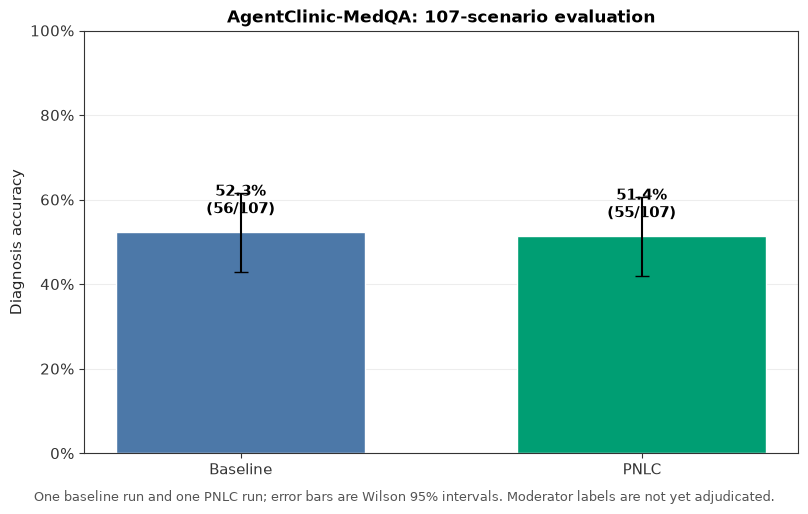

Saved /Users/abhineetkumar/Desktop/pnlc/pnlc-agentclinic/docs/figures/agentclinic_107_performance.png


In [6]:
labels = accuracy_summary["run"].tolist()
rates = accuracy_summary["accuracy"].to_numpy()
lower = accuracy_summary["wilson_95_low"].to_numpy()
upper = accuracy_summary["wilson_95_high"].to_numpy()
errors = np.vstack([rates - lower, upper - rates])

fig, ax = plt.subplots(figsize=(8.2, 5.0))
x = np.arange(len(labels))
ax.bar(x, rates, yerr=errors, capsize=5, width=0.62, color=[COLORS[label] for label in labels], edgecolor="white")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Diagnosis accuracy")
ax.set_title("AgentClinic-MedQA: 107-scenario evaluation")
ax.grid(axis="y", alpha=0.22)
ax.set_axisbelow(True)
for index, row in accuracy_summary.iterrows():
    ax.text(index, row["accuracy"] + 0.045, f"{row['accuracy']:.1%}\n({int(row['correct'])}/107)", ha="center", fontweight="bold")
fig.text(0.5, -0.015, "One baseline run and one PNLC run; error bars are Wilson 95% intervals. Moderator labels are not yet adjudicated.", ha="center", fontsize=9, color="#555555")
fig.tight_layout()
path = FIGURE_DIR / "agentclinic_107_performance.png"
fig.savefig(path, dpi=240, bbox_inches="tight")
plt.show()
print(f"Saved {path.resolve()}")


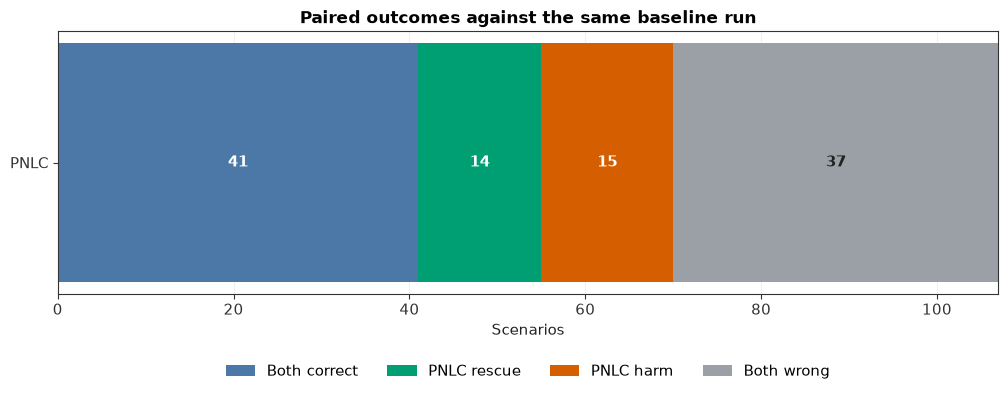

Saved /Users/abhineetkumar/Desktop/pnlc/pnlc-agentclinic/docs/figures/agentclinic_107_paired_outcomes.png


In [7]:
fig, ax = plt.subplots(figsize=(10.2, 4.2))
y = np.arange(len(paired_summary))
left = np.zeros(len(paired_summary))
for outcome in outcome_order:
    values = paired_summary[outcome].to_numpy()
    ax.barh(y, values, left=left, color=COLORS[outcome], label=outcome, height=0.58)
    for row_index, (start, value) in enumerate(zip(left, values)):
        if value >= 7:
            text_color = "#222222" if outcome == "Both wrong" else "white"
            ax.text(start + value / 2, row_index, str(int(value)), ha="center", va="center", color=text_color, fontweight="bold")
    left += values
ax.set_yticks(y, paired_summary["comparison"].str.replace("Baseline vs ", "", regex=False))
ax.set_xlim(0, EXPECTED_SCENARIOS)
ax.set_xlabel("Scenarios")
ax.set_title("Paired outcomes against the same baseline run")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False)
ax.grid(axis="x", alpha=0.18)
ax.set_axisbelow(True)
fig.tight_layout()
path = FIGURE_DIR / "agentclinic_107_paired_outcomes.png"
fig.savefig(path, dpi=240, bbox_inches="tight")
plt.show()
print(f"Saved {path.resolve()}")


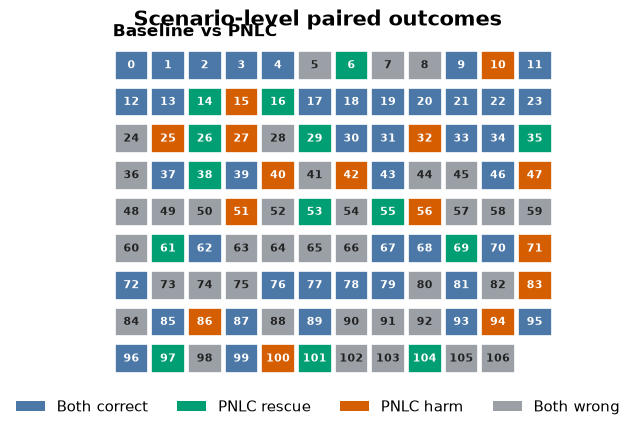

Saved /Users/abhineetkumar/Desktop/pnlc/pnlc-agentclinic/docs/figures/agentclinic_107_scenario_map.png


In [8]:
columns = 12
rows = math.ceil(EXPECTED_SCENARIOS / columns)
fig, ax = plt.subplots(figsize=(12.5, 4.2))
for ax, (label, comparison) in zip([ax], comparisons.items()):
    scenario_map = comparison[["scenario_index", "outcome"]].sort_values("scenario_index")
    for position, row in enumerate(scenario_map.itertuples(index=False)):
        grid_row = position // columns
        grid_col = position % columns
        y_pos = rows - 1 - grid_row
        tile = plt.Rectangle((grid_col, y_pos), 0.92, 0.78, facecolor=COLORS[row.outcome], edgecolor="white", linewidth=1.2)
        ax.add_patch(tile)
        ax.text(grid_col + 0.46, y_pos + 0.39, str(row.scenario_index), ha="center", va="center", fontsize=7.6,
                color="white" if row.outcome != "Both wrong" else "#222222", fontweight="bold")
    ax.set_xlim(-0.05, columns)
    ax.set_ylim(-0.05, rows)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"Baseline vs {label}", loc="left", pad=5)
handles = [Patch(facecolor=COLORS[outcome], label=outcome) for outcome in outcome_order]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)
fig.suptitle("Scenario-level paired outcomes", fontsize=15, fontweight="bold", y=0.99)
fig.subplots_adjust(top=0.91, bottom=0.12, hspace=0.23)
path = FIGURE_DIR / "agentclinic_107_scenario_map.png"
fig.savefig(path, dpi=240, bbox_inches="tight")
plt.show()
print(f"Saved {path.resolve()}")


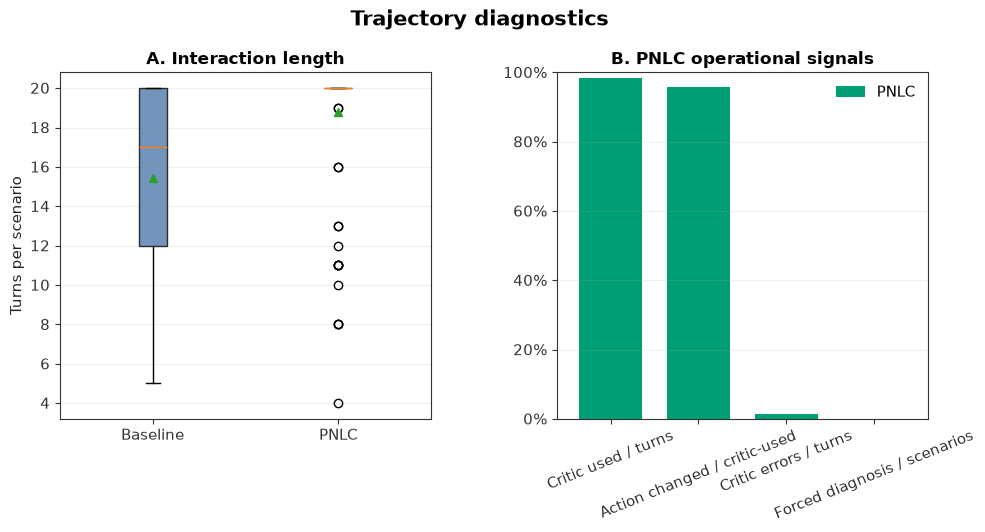

Saved /Users/abhineetkumar/Desktop/pnlc/pnlc-agentclinic/docs/figures/agentclinic_107_trajectory_diagnostics.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5), gridspec_kw={"wspace": 0.34})
turn_data = [scenario_turn_tables[label]["turns"].to_numpy() for label in ["Baseline", "PNLC"]]
box = axes[0].boxplot(turn_data, tick_labels=["Baseline", "PNLC"], patch_artist=True, showmeans=True)
for patch, label in zip(box["boxes"], ["Baseline", "PNLC"]):
    patch.set_facecolor(COLORS[label])
    patch.set_alpha(0.78)
axes[0].set_ylabel("Turns per scenario")
axes[0].set_title("A. Interaction length")
axes[0].grid(axis="y", alpha=0.2)

pnlc_ops = trajectory_summary.set_index("run").loc[["PNLC"]]
operation_rates = pd.DataFrame({
    "Critic used / turns": pnlc_ops["critic_used_turns"] / pnlc_ops["turns"],
    "Action changed / critic-used": pnlc_ops["change_rate_when_used"],
    "Critic errors / turns": pnlc_ops["critic_error_turns"] / pnlc_ops["turns"],
    "Forced diagnosis / scenarios": pnlc_ops["forced_diagnosis_scenarios"] / EXPECTED_SCENARIOS,
})
operation_rates.T.plot.bar(ax=axes[1], color=[COLORS["PNLC"]], width=0.72)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("B. PNLC operational signals")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=22)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.2)
fig.suptitle("Trajectory diagnostics", fontsize=15, fontweight="bold", y=1.02)
path = FIGURE_DIR / "agentclinic_107_trajectory_diagnostics.png"
fig.savefig(path, dpi=240, bbox_inches="tight")
plt.show()
print(f"Saved {path.resolve()}")


## 6. Interpretation boundary

The accuracy and paired plots answer whether the completed runs differ descriptively. They do **not** establish the proposed knowledge-grounding failure. That claim requires manual trajectory labels showing the chain **defective imagined future → critic accepts or prefers it → refinement preserves or amplifies it**, followed by oracle or retrieval-grounded replay at the same saved decision state.

In [10]:
def show_scenario(scenario_index, pnlc_run="PNLC"):
    """Display the paired result and turn-level baseline/PNLC trajectories."""
    if pnlc_run not in comparisons:
        raise KeyError(f"Choose one of {list(comparisons)}")
    display(comparisons[pnlc_run].loc[comparisons[pnlc_run]["scenario_index"] == scenario_index])
    baseline_columns = ["turn_index", "incoming_message", "thought", "doctor_action", "parsed_ok"]
    pnlc_columns = [
        "turn_index", "incoming_message", "critic_initial_action", "doctor_action",
        "critic_changed_action", "thought", "parsed_ok", "critic_error", "forced_diagnosis_used",
    ]
    print("Baseline trajectory")
    display(trajectory_frames["Baseline"].loc[
        trajectory_frames["Baseline"]["scenario_index"] == scenario_index, baseline_columns
    ].sort_values("turn_index"))
    print(f"{pnlc_run} trajectory")
    display(trajectory_frames[pnlc_run].loc[
        trajectory_frames[pnlc_run]["scenario_index"] == scenario_index, pnlc_columns
    ].sort_values("turn_index"))


print("Use show_scenario(<scenario_id>) for manual review.")


Use show_scenario(<scenario_id>) for manual review.
